# StormHacks 2026: VPD incident data cleaning (data-pipeline branch)

**Purpose.** Turn the raw Vancouver Police Department (VPD) GeoDASH open-data export into one tidy table of **reported incidents per neighbourhood per month**. The ML owner trains the one-month-ahead forecast on it, the backend serves it, and the frontend map draws it. Run the cells top to bottom (Run All). The working directory must be `data/`. Full context for teammates and AI assistants is in `data/README.md`.

**Input:** `raw/vancouver_crime_data.csv`: 962,117 incident rows, 2003-01 to 2026-09-25. This is the VPD "All Neighbourhoods, All Years" export plus the separately downloaded 2022 file, because the all-years export is missing 2022.

**Output:** `processed/neighbourhood_monthly.csv`: 6,840 rows (24 neighbourhoods x 285 months, 2003-01 to 2026-09), with columns `year, month, month_str, neighbourhood, incident_count`, one count column per type (`other_theft` ... `theft_of_bicycle`, eight in all, summing to `incident_count`), and `is_partial`.

**Decisions made here**
- **Rows with a blank neighbourhood are dropped** (106 rows). They cannot be placed on the map.
- **Three types are excluded:** both *Vehicle Collision or Pedestrian Struck* types, because they are traffic events and VPD changed how it recorded them in 2014, and *Homicide*, because it is about one per month city-wide and must never be forecast or mapped.
- **Duplicate rows are not removed.** VPD blanks the time, block and coordinates of *Offence Against a Person* records for privacy, so many separate incidents look identical. Each row is a real incident.
- **The neighbourhood x month grid is complete.** Months with no incidents get `incident_count = 0` (18 cells, all Musqueam).
- **September 2026 is partial** (the data ends 2026-09-25), so it is flagged with `is_partial = 1`. The last complete month is 2026-08.


## 0. Load the raw data
Reads the combined raw file (the all-years export with 2022 added back in) and shows the first 5 rows. Expect **962,117 rows** and 10 columns: `TYPE, YEAR, MONTH, DAY, HOUR, MINUTE, HUNDRED_BLOCK, NEIGHBOURHOOD, X, Y`. X/Y are UTM zone 10N metres, not latitude/longitude. Only `TYPE`, `YEAR`, `MONTH` and `NEIGHBOURHOOD` are used later. The raw file is never modified.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("raw/vancouver_crime_data.csv")
df.head()

,TYPE,YEAR,MONTH,DAY,HOUR,MINUTE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y
0,Break and Enter Commercial,2023,9,14,3,30,10XX ALBERNI ST,West End,491065.2962,5.459130e+06
1,Break and Enter Commercial,2024,2,24,4,8,10XX BARCLAY ST,West End,490865.2076,5.458841e+06
2,Break and Enter Commercial,2023,4,1,4,7,10XX BEACH AVE,West End,490197.8719,5.458239e+06
3,Break and Enter Commercial,2025,4,28,12,5,10XX BEACH AVE,West End,490227.2225,5.458210e+06
4,Break and Enter Commercial,2023,5,11,18,0,10XX BEACH AVE,Central Business District,490249.2307,5.458167e+06


## 1. Drop rows with no neighbourhood
A few rows have an empty `NEIGHBOURHOOD`. They are mostly privacy-offset violent offences and collisions that VPD never assigned to an area. We cannot place them on a neighbourhood map. We also do **not** guess the area from X/Y, because those coordinates are blanked or offset. Expect: **106 dropped, 962,011 remain**.

In [2]:
before = len(df)
df = df.dropna(subset=["NEIGHBOURHOOD"])
df = df[df["NEIGHBOURHOOD"].str.strip() != ""]   # also catches empty strings
print(f"Dropped {before - len(df):,} rows with no neighbourhood. {len(df):,} rows remain.")

Dropped 106 rows with no neighbourhood. 962,011 rows remain.


## 2. Build a `YYYY-MM` month key
Combines `YEAR` and `MONTH` into one text column, `MONTH_STR` (for example `2023-09`). The month is zero-padded, so sorting the text also sorts by time. This is the month format the whole team agreed on. The row count does not change (still 962,011). The table preview shows the new column at the far right.

In [3]:
df["MONTH_STR"] = df["YEAR"].astype(str) + "-" + df["MONTH"].astype(str).str.zfill(2)
df.head()

,TYPE,YEAR,MONTH,DAY,HOUR,MINUTE,HUNDRED_BLOCK,NEIGHBOURHOOD,X,Y,MONTH_STR
0,Break and Enter Commercial,2023,9,14,3,30,10XX ALBERNI ST,West End,491065.2962,5.459130e+06,2023-09
1,Break and Enter Commercial,2024,2,24,4,8,10XX BARCLAY ST,West End,490865.2076,5.458841e+06,2024-02
2,Break and Enter Commercial,2023,4,1,4,7,10XX BEACH AVE,West End,490197.8719,5.458239e+06,2023-04
3,Break and Enter Commercial,2025,4,28,12,5,10XX BEACH AVE,West End,490227.2225,5.458210e+06,2025-04
4,Break and Enter Commercial,2023,5,11,18,0,10XX BEACH AVE,Central Business District,490249.2307,5.458167e+06,2023-05


## 3. Look: incidents by type (before filtering)
A horizontal bar chart counting every incident type still in the data. It shows **11 types**, including the two vehicle-collision types and Homicide that the next steps remove. This chart only explores the data and changes nothing.

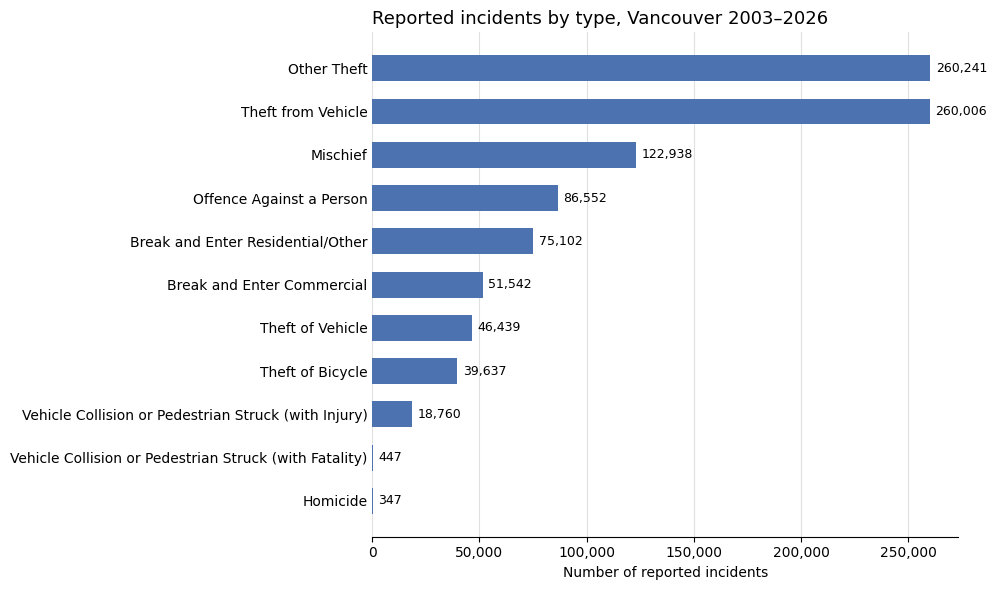

In [4]:
type_counts = df["TYPE"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(type_counts.index, type_counts.values, color="#4C72B0", height=0.6)

# direct labels on each bar
for bar, value in zip(bars, type_counts.values):
    ax.text(bar.get_width() + max(type_counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}", va="center", fontsize=9)

ax.set_title("Reported incidents by type, Vancouver 2003–2026", fontsize=13, loc="left")
ax.set_xlabel("Number of reported incidents")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", color="#e0e0e0", linewidth=0.8)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

## 4. Look: why vehicle collisions are excluded
Plots vehicle collisions per year, 2003-2025. Counts sit between **about 160 and 350 per year up to 2013** (337 in 2013), then jump to **1,568 in 2014** and stay around 850-1,700 per year after that. That jump comes from a change in how VPD recorded collisions, not from a real change on the roads. A model would learn a false trend from it, which is the evidence for dropping these types in the next cell.

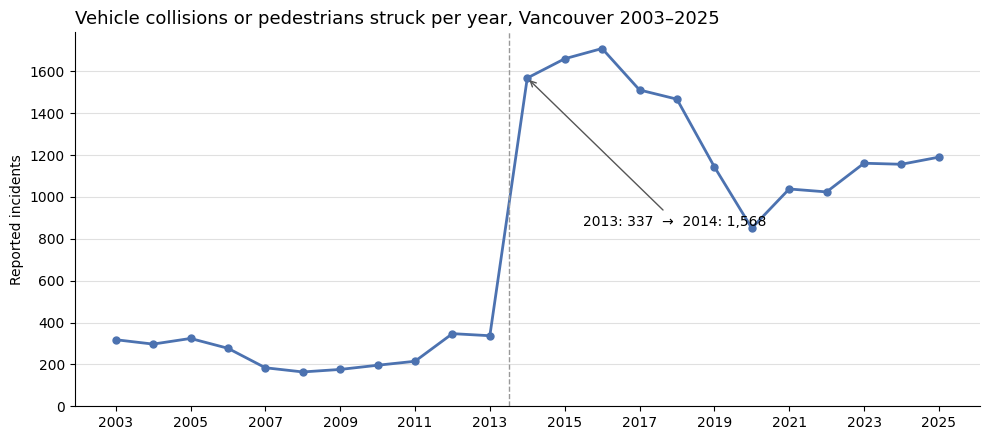

In [5]:
collisions = (
    df[df["TYPE"].str.startswith("Vehicle Collision") & (df["YEAR"] < 2026)]
      .groupby("YEAR").size()
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.plot(collisions.index, collisions.values, color="#4C72B0", linewidth=2, marker="o", markersize=5)

ax.axvline(2013.5, color="#999999", linestyle="--", linewidth=1)
ax.annotate(f"2013: {collisions[2013]:,}  →  2014: {collisions[2014]:,}",
            xy=(2014, collisions[2014]), xytext=(2015.5, collisions[2014] * 0.55),
            arrowprops=dict(arrowstyle="->", color="#555555"), fontsize=10)

ax.set_title("Vehicle collisions or pedestrians struck per year, Vancouver 2003–2025", fontsize=13, loc="left")
ax.set_ylabel("Reported incidents")
ax.set_xticks(range(2003, 2026, 2))
ax.set_ylim(0)
ax.grid(axis="y", color="#e0e0e0", linewidth=0.8)
ax.set_axisbelow(True)
for side in ["top", "right"]:
    ax.spines[side].set_visible(False)

plt.tight_layout()
plt.show()

## 5. Exclude collisions and homicide
Removes the two *Vehicle Collision or Pedestrian Struck* types (traffic events with the 2014 recording break) and *Homicide* (about one per month city-wide, so too rare to forecast, and it must never be mapped). Expect **19,554 dropped, 942,457 remain**, with **8 types** left. The largest are Other Theft (260,241) and Theft from Vehicle (260,006). No `drop_duplicates` is used here or anywhere else.

In [6]:
DROP_TYPES = [
    "Vehicle Collision or Pedestrian Struck (with Injury)",
    "Vehicle Collision or Pedestrian Struck (with Fatality)",
    "Homicide",
]

before = len(df)
df = df[~df["TYPE"].isin(DROP_TYPES)]
print(f"Dropped {before - len(df):,} rows. {len(df):,} rows remain.")

df["TYPE"].value_counts()

Dropped 19,554 rows. 942,457 rows remain.


TYPE
Other Theft                          260241
Theft from Vehicle                   260006
Mischief                             122938
Offence Against a Person              86552
Break and Enter Residential/Other     75102
Break and Enter Commercial            51542
Theft of Vehicle                      46439
Theft of Bicycle                      39637
Name: count, dtype: int64

## 6. Look: the 8 types we keep
The same bar chart as step 3, redrawn after filtering. It should show exactly **8 types**: Other Theft, Theft from Vehicle, Mischief, Offence Against a Person, Break and Enter Residential/Other, Break and Enter Commercial, Theft of Vehicle, Theft of Bicycle. These 8 are summed together into `incident_count`, and each one also gets its own count column in the output so the ML owner can build a severity-weighted index.

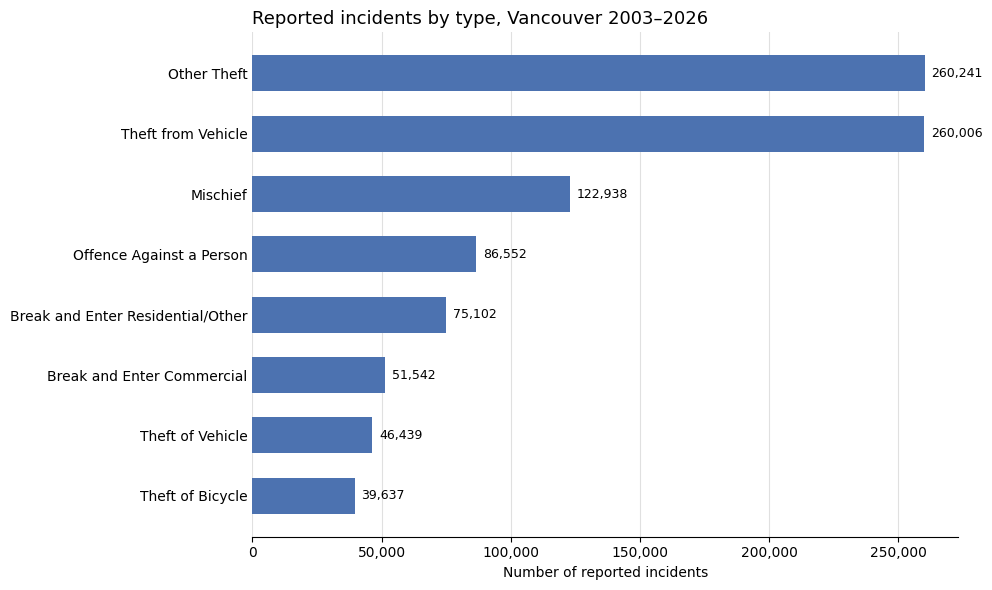

In [7]:
type_counts = df["TYPE"].value_counts().sort_values()

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(type_counts.index, type_counts.values, color="#4C72B0", height=0.6)

# direct labels on each bar
for bar, value in zip(bars, type_counts.values):
    ax.text(bar.get_width() + max(type_counts.values) * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{value:,}", va="center", fontsize=9)

ax.set_title("Reported incidents by type, Vancouver 2003–2026", fontsize=13, loc="left")
ax.set_xlabel("Number of reported incidents")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.grid(axis="x", color="#e0e0e0", linewidth=0.8)
ax.set_axisbelow(True)
for side in ["top", "right", "left"]:
    ax.spines[side].set_visible(False)
ax.tick_params(axis="y", length=0)

plt.tight_layout()
plt.show()

## 7. Look: monthly totals for every year
A small chart for each year, 2003-2026, showing city-wide incidents per month. Check that every month has data, including 2022, which had to be downloaded separately. The **hatched bar is September 2026**: the data stops on 2026-09-25, so that month looks low and must not be read as a real drop. You can also see the 2020-21 COVID dip.

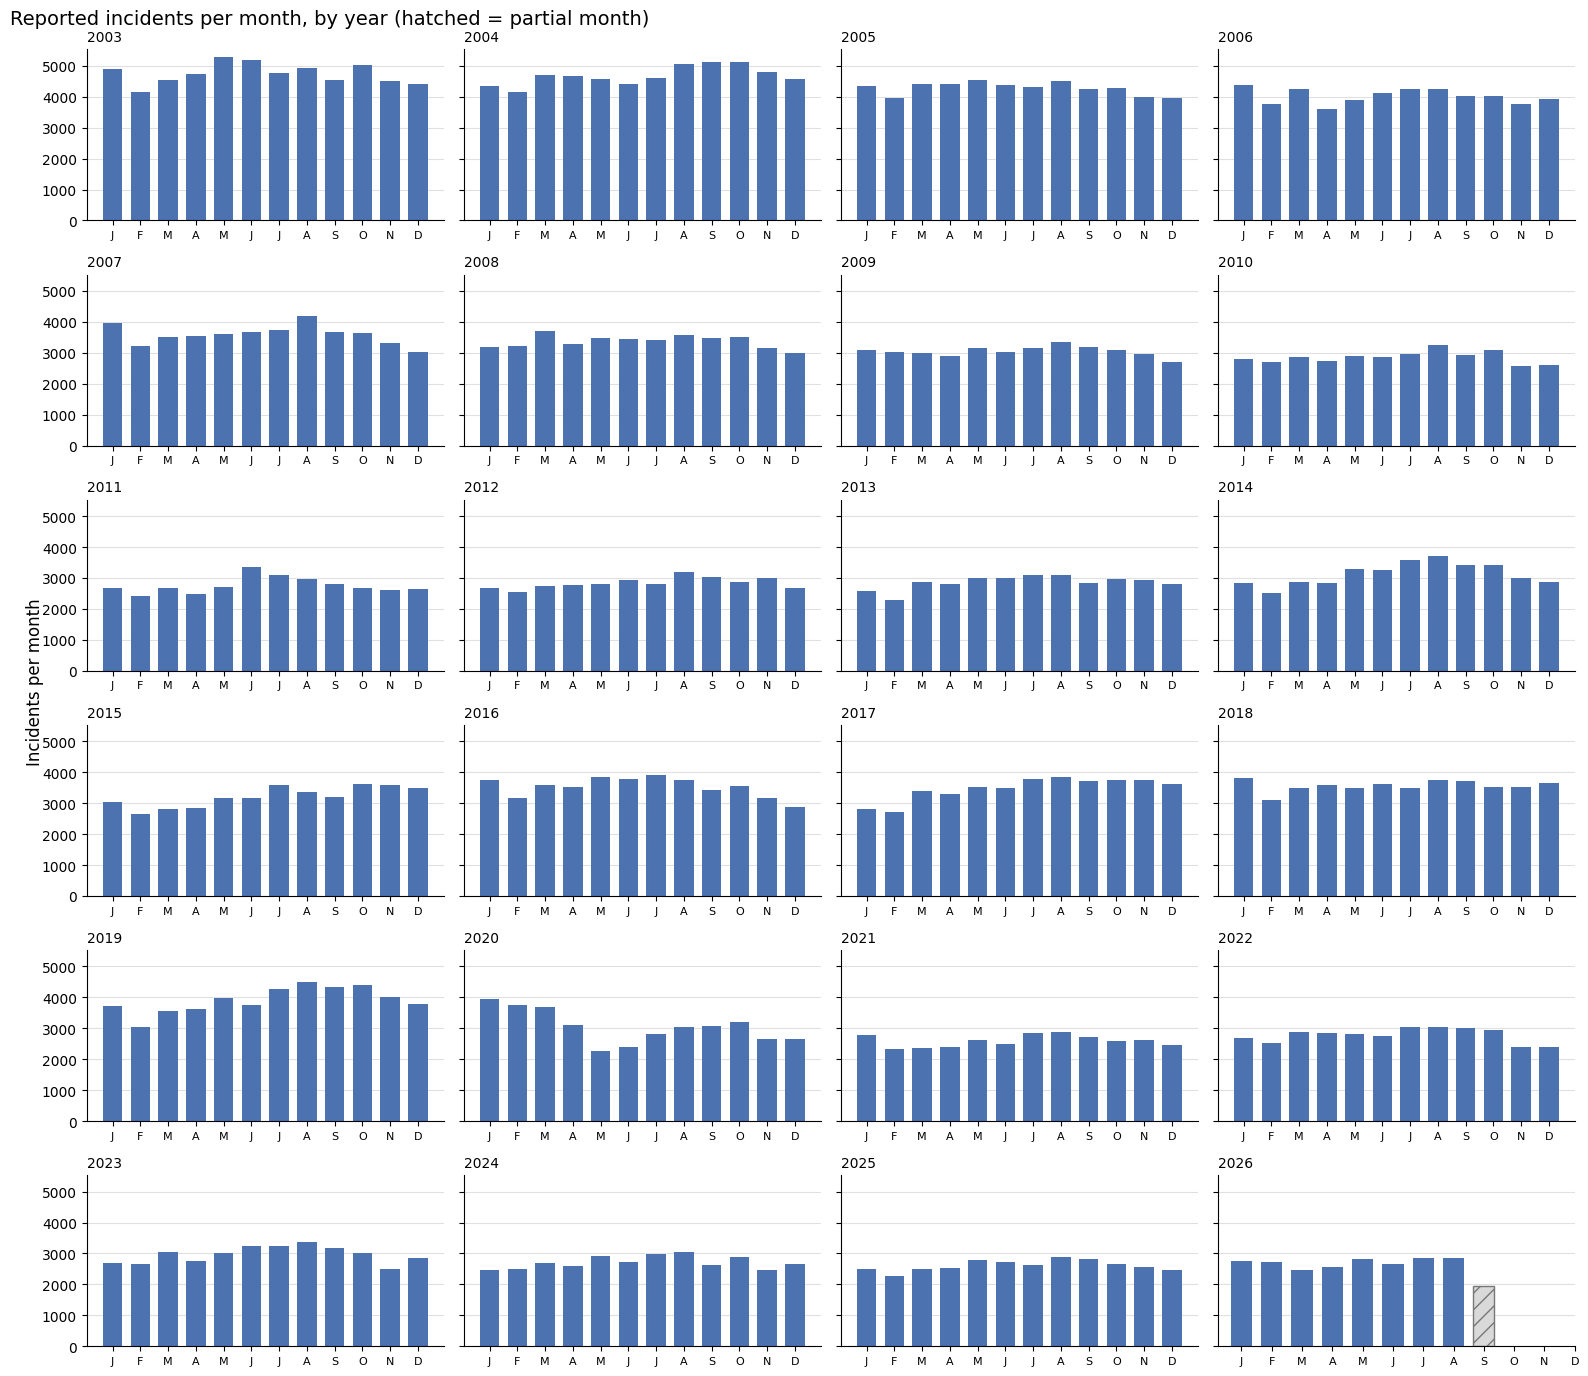

In [8]:
per_month = df.groupby(["YEAR", "MONTH"]).size().unstack("MONTH")

last_year  = df["YEAR"].max()
last_month = df.loc[df["YEAR"] == last_year, "MONTH"].max()

years = per_month.index.tolist()
fig, axes = plt.subplots(6, 4, figsize=(16, 14), sharey=True)

for ax, year in zip(axes.flat, years):
    counts = per_month.loc[year]
    for m, v in counts.items():
        partial = (year == last_year and m == last_month)
        ax.bar(m, v, width=0.7,
               color="#d9d9d9" if partial else "#4C72B0",
               hatch="//" if partial else None, edgecolor="#777777" if partial else "none")
    ax.set_title(str(year), fontsize=10, loc="left")
    ax.set_xticks(range(1, 13))
    ax.set_xticklabels(list("JFMAMJJASOND"), fontsize=8)
    ax.grid(axis="y", color="#e0e0e0", linewidth=0.8)
    ax.set_axisbelow(True)
    for side in ["top", "right"]:
        ax.spines[side].set_visible(False)

for ax in axes.flat[len(years):]:
    ax.set_visible(False)

fig.suptitle("Reported incidents per month, by year (hatched = partial month)",
             fontsize=14, x=0.01, ha="left")
fig.supylabel("Incidents per month")
plt.tight_layout()
plt.show()

## 8. Count per neighbourhood-month and fill the gaps with 0
Groups rows by neighbourhood and month, overall and one column per incident type, then builds the complete grid so every neighbourhood has every month. Expect **24 neighbourhoods x 285 months = 6,840 rows**, with **18 zero-count cells, all in Musqueam** (a very small area). These zeros are real, because VPD published every month from 2003-01 to 2026-09.

In [9]:
# Map each kept TYPE to a column name. Order here = column order in the output.
TYPE_COLUMNS = {
    "Other Theft":                       "other_theft",
    "Theft from Vehicle":                "theft_from_vehicle",
    "Mischief":                          "mischief",
    "Offence Against a Person":          "offence_against_a_person",
    "Break and Enter Residential/Other": "break_and_enter_residential_other",
    "Break and Enter Commercial":        "break_and_enter_commercial",
    "Theft of Vehicle":                  "theft_of_vehicle",
    "Theft of Bicycle":                  "theft_of_bicycle",
}
assert set(df["TYPE"].unique()) == set(TYPE_COLUMNS), "unexpected TYPE values"

# 1. count incidents per neighbourhood-month: overall, and one column per type
monthly = df.groupby(["NEIGHBOURHOOD", "MONTH_STR"]).size().rename("incident_count").to_frame()
per_type = (
    pd.crosstab([df["NEIGHBOURHOOD"], df["MONTH_STR"]], df["TYPE"])
      .reindex(columns=list(TYPE_COLUMNS), fill_value=0)
      .rename(columns=TYPE_COLUMNS)
)
monthly = monthly.join(per_type)

# 2. build every neighbourhood × every month, and fill the missing ones with 0
all_months = pd.period_range(df["MONTH_STR"].min(), df["MONTH_STR"].max(), freq="M").strftime("%Y-%m")
all_areas  = sorted(df["NEIGHBOURHOOD"].unique())
full_index = pd.MultiIndex.from_product([all_areas, all_months], names=["NEIGHBOURHOOD", "MONTH_STR"])

monthly_full = monthly.reindex(full_index, fill_value=0).reset_index()

type_cols = list(TYPE_COLUMNS.values())
assert (monthly_full[type_cols].sum(axis=1) == monthly_full["incident_count"]).all(), "type columns must sum to incident_count"

print(f"{len(all_areas)} neighbourhoods × {len(all_months)} months = {len(monthly_full):,} rows")
print(f"Zero-count months filled in: {(monthly_full['incident_count'] == 0).sum()}")
monthly_full[monthly_full["incident_count"] == 0]


24 neighbourhoods × 285 months = 6,840 rows
Zero-count months filled in: 18


,NEIGHBOURHOOD,MONTH_STR,incident_count,other_theft,theft_from_vehicle,mischief,offence_against_a_person,break_and_enter_residential_other,break_and_enter_commercial,theft_of_vehicle,theft_of_bicycle
3475,Musqueam,2007-08,0,0,0,0,0,0,0,0,0
3476,Musqueam,2007-09,0,0,0,0,0,0,0,0,0
3479,Musqueam,2007-12,0,0,0,0,0,0,0,0,0
3482,Musqueam,2008-03,0,0,0,0,0,0,0,0,0
3587,Musqueam,2016-12,0,0,0,0,0,0,0,0,0
3593,Musqueam,2017-06,0,0,0,0,0,0,0,0,0
3601,Musqueam,2018-02,0,0,0,0,0,0,0,0,0
3619,Musqueam,2019-08,0,0,0,0,0,0,0,0,0
3630,Musqueam,2020-07,0,0,0,0,0,0,0,0,0
3636,Musqueam,2021-01,0,0,0,0,0,0,0,0,0


## 9. Export `processed/neighbourhood_monthly.csv`
Splits the month into `year` and `month`, renames the columns to lowercase, and adds `is_partial` (1 only for 2026-09, the last and incomplete month). The asserts confirm the counts add up to exactly the 942,457 cleaned rows, that the eight type columns sum to `incident_count` on every row, and that each type column matches the raw rows, so nothing was lost or double-counted. Expect shape **(6840, 14)**. This file is what ML, backend and frontend consume.

In [10]:
out = monthly_full.copy()
out["year"]       = out["MONTH_STR"].str[:4].astype(int)
out["month"]      = out["MONTH_STR"].str[5:].astype(int)
out["is_partial"] = (out["MONTH_STR"] == out["MONTH_STR"].max()).astype(int)   # flags 2026-09 only

out = (
    out.rename(columns={"MONTH_STR": "month_str", "NEIGHBOURHOOD": "neighbourhood"})
       [["year", "month", "month_str", "neighbourhood", "incident_count", *type_cols, "is_partial"]]
       .sort_values(["neighbourhood", "month_str"])
       .reset_index(drop=True)
)

# checks: nothing lost, nothing double-counted, per-type columns consistent with the raw rows
assert out["incident_count"].sum() == len(df), "counts do not add up to the cleaned rows"
assert (out[type_cols].sum(axis=1) == out["incident_count"]).all(), "type columns must sum to incident_count on every row"
raw_type_counts = df["TYPE"].map(TYPE_COLUMNS).value_counts()
assert all(out[c].sum() == raw_type_counts[c] for c in type_cols), "a type column does not match the raw rows"
assert out[type_cols].ge(0).all().all() and out[type_cols].dtypes.eq("int64").all(), "type columns must be non-negative integers"

out.to_csv("processed/neighbourhood_monthly.csv", index=False)

print(out.shape)
out.head()


(6840, 14)


,year,month,month_str,neighbourhood,incident_count,other_theft,theft_from_vehicle,mischief,offence_against_a_person,break_and_enter_residential_other,break_and_enter_commercial,theft_of_vehicle,theft_of_bicycle,is_partial
0,2003,1,2003-01,Arbutus Ridge,85,13,15,6,4,32,2,12,1,0
1,2003,2,2003-02,Arbutus Ridge,54,11,17,10,1,11,1,3,0,0
2,2003,3,2003-03,Arbutus Ridge,69,11,20,10,3,8,5,12,0,0
3,2003,4,2003-04,Arbutus Ridge,70,13,18,9,2,16,4,8,0,0
4,2003,5,2003-05,Arbutus Ridge,53,16,12,6,1,9,3,4,2,0
